# Bees production 

### Setup

In [ ]:
import numpy as np
import pandas as pd 
import seaborn as sns
import utils
import matplotlib.pyplot as plt
import importlib
importlib.reload(utils)

honey_production_df, apistox_df, inspections_on_weather_dict = utils.load_base_datasets()
honey_production_df_copy = honey_production_df.copy()


 honey_production_df (1115, 9) : Done! 

 apistox_df (1035, 13) : Done! 

 Apiary_Information.csv (13, 4) : Done!
 HCC_Inspections.csv (2404, 11) : Done!
 Hive_Information.csv (188, 3) : Done!
 Hourly_Weather.csv (3672, 15) : Done!
 Weather_Observations.csv (1776, 4) : Done!
 Weather_Stations.csv (3, 3) : Done!

Datasets collection completed.


## Part 1: Honey production 

In [60]:
honey_production_df = honey_production_df_copy.copy()

#cleaning the dataset
for state in honey_production_df.state.unique():
    state_production = honey_production_df.loc[honey_production_df.state == state]
    #keeping states that have data for all the 27 years from 1995 to 2021
    if len(state_production) < 27:
        honey_production_df.drop(state_production.index, inplace=True)

n_states = honey_production_df.state.nunique()
utils.EDA(honey_production_df, head = n_states) #show the first data for all the states

honey_production_df_copy = honey_production_df.copy()

##-------------- INFO ------------------------------##

<class 'pandas.core.frame.DataFrame'>
Index: 1026 entries, 0 to 1114
Data columns (total 8 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   state                1026 non-null   object 
 1   colonies_number      1026 non-null   int64  
 2   yield_per_colony     1026 non-null   int64  
 3   production           1026 non-null   int64  
 4   stocks               1026 non-null   int64  
 5   average_price        1026 non-null   float64
 6   value_of_production  1026 non-null   int64  
 7   year                 1026 non-null   int64  
dtypes: float64(1), int64(6), object(1)
memory usage: 72.1+ KB


##-------------- DESCRIBE --------------------------##
        colonies_number  yield_per_colony    production        stocks  \
count      1026.000000       1026.000000  1.026000e+03  1.026000e+03   
mean      67181.286550         60.496101  3.071741e+06  1.265299e+06   
std   

### Production Analysis 

In [ ]:
utils.plot_all(honey_production_df, "state", "year", "yield_per_colony")

### Production Trend Prediction

Score: 0.7474881577512745


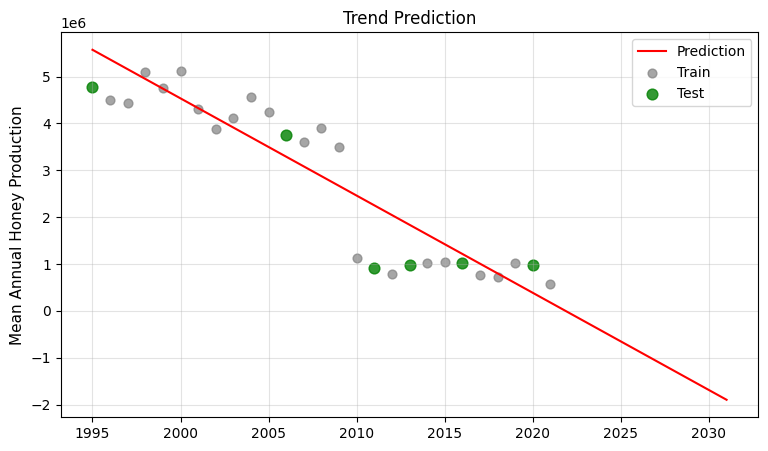

In [ ]:
years = honey_production_df['year'].unique()
production_means = honey_production_df.groupby("year")["production"].mean()
  
utils.linear_regression_and_plot(x_array=years, 
                           pred_x_array=np.concatenate([years,np.arange(2022, 2032)]), 
                           y_array=production_means,
                           train_size=0.8, 
                           random_state=30, 
                           ylabel = "Mean Annual Honey Production")

### Price analysis

In [ ]:
figure = plt.figure(figsize=(16,5))
plot1 = figure.add_subplot(1,2,1)
plot2 = figure.add_subplot(1,2,2)
plot1.plot(honey_production_df.year.unique(), honey_production_df.groupby("year")["stocks"].mean(), label = "stocks hold")
plot1.plot(honey_production_df.year.unique(), honey_production_df.groupby("year")["production"].mean(), label = "production")
plot2.plot(honey_production_df.year.unique(), honey_production_df.groupby("year")["value_of_production"].mean(), label = "Global price ($)", color = "green")
plot1.legend()
plot2.legend()
plot1.grid(alpha = 0.3)
plot2.grid(alpha = 0.3)

### Price Trend Prediction 

Score: 0.7956242692150794


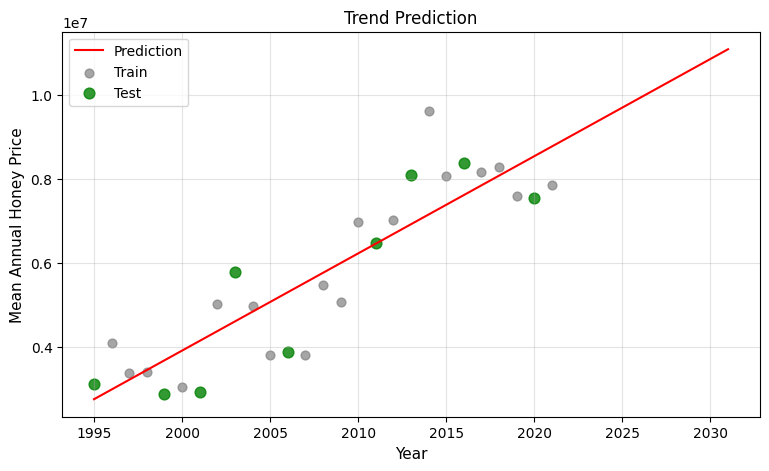

In [ ]:
years = honey_production_df['year'].unique()
value_production_means = honey_production_df.groupby("year")["value_of_production"].mean()

utils.linear_regression_and_plot(years, y_array=value_production_means,
                                 pred_x_array=np.concatenate([years,np.arange(2022, 2032)]),
                                 random_state=30,
                                 xlabel="Year",
                                 ylabel = "Mean Annual Honey Price")

## Part 2: Apistox 

In [ ]:
utils.EDA(apistox_df, head = 7)

### Further setup

In [ ]:
#the following function alone can be of interest therefore made autonomous
#pesticide_usage_df = utils.load_pesticide_usage_datasets()

pesticide_usage_df = utils.load_apistox_support_dataframe(remove_kg=False)

apistox_complete_df = apistox_df.merge(pesticide_usage_df)
apistox_complete_df.drop(["name", "source", "SMILES", "CID","other_agrochemical", "year"], axis = 1, inplace=True)
apistox_complete_df.columns = apistox_complete_df.columns.map(str.upper)

apistox_complete_df_copy = apistox_complete_df.copy()


### Apistox analysis and Classification 

In [ ]:
utils.EDA(apistox_complete_df)

#### Variety of Pesticides

In [ ]:
first_target = apistox_complete_df.PPDB_LEVEL
second_target = apistox_complete_df.LABEL

results, _ = utils.random_forest(apistox_complete_df[["HERBICIDE", "FUNGICIDE", "INSECTICIDE", "TOXICITY_TYPE"]],
                    first_target,
                    n_estimators=750,
                    random_state=42)
results

In [ ]:
apistox_complete_df = apistox_complete_df_copy

results_feature_indexed = results.set_index("Features")

# #correctly giving weight to the information we are interested in
apistox_complete_df = apistox_complete_df.groupby("STATE_NAME")[["INSECTICIDE","HERBICIDE", "FUNGICIDE"]].sum()
apistox_complete_df["ORDER"] = 0
for column in apistox_complete_df.columns[:3]:
    #:TODO fallo con iloc
    apistox_complete_df["ORDER"] += apistox_complete_df[column] * float(results_feature_indexed.loc[column])

apistox_complete_df = apistox_complete_df.sort_values("ORDER", ascending=False).drop("ORDER", axis = 1)
utils.bar_all(apistox_complete_df,apistox_complete_df.columns,["INSECTICIDE","HERBICIDE", "FUNGICIDE"])

variety_order = apistox_complete_df.reset_index()["STATE_NAME"].rename("VARIETY_ORDER")

#### Quantity of Pesticides

In [ ]:
apistox_complete_df = apistox_complete_df_copy
first_target = apistox_complete_df.PPDB_LEVEL
second_target = apistox_complete_df.LABEL

results_label, _ = utils.random_forest(apistox_complete_df[["HERBICIDE", "FUNGICIDE", "INSECTICIDE", "TOXICITY_TYPE", "MEAN_KG"]],
                    first_target,
                    n_estimators=750,
                    random_state=42)
print("Impact on label:\n", results_label)
print("...........")
results_level, _ = utils.random_forest(apistox_complete_df[["HERBICIDE", "FUNGICIDE", "INSECTICIDE", "TOXICITY_TYPE", "MEAN_KG"]],
                    second_target,
                    n_estimators=750,
                    random_state=42)
print("Impact on PPDB_LEVEL:\n", results_level)

#### Comparison
(required to run the two subsections above before this)

In [ ]:
apistox_complete_df = apistox_complete_df_copy
apistox_complete_df = apistox_complete_df.groupby("STATE_NAME")[["MEAN_KG"]].sum().sort_values("MEAN_KG", ascending=False).reset_index()["STATE_NAME"].rename("QUANTITY_ORDER")

usage_ranking_df = pd.concat([variety_order, apistox_complete_df], axis = 1)

variety_order_idx = usage_ranking_df.index.to_list()
quantity_order_idx = []
for state in usage_ranking_df.VARIETY_ORDER:
    #TODO loc
    quantity_order_idx.append(usage_ranking_df[usage_ranking_df["QUANTITY_ORDER"] == state].index[0])

usage_ranking_df["POS_DIFF"] = np.abs(pd.Series(variety_order_idx) - pd.Series(quantity_order_idx))

conditions = [
    usage_ranking_df["POS_DIFF"] == 0,
    usage_ranking_df["POS_DIFF"] <= 3, 
    usage_ranking_df["POS_DIFF"] <= 5,
    usage_ranking_df["POS_DIFF"] <= 10,
]

distance_labels = ["SAME POSITION", "VERY CLOSE", "CLOSE", "DISTANT"]

usage_ranking_df["POS_CHANGE"] = np.select(conditions, distance_labels, "VERY DISTANT")
usage_ranking_df.drop("POS_DIFF",axis=1, inplace =True)
usage_ranking_df

## Part 3: Weather Effects on Bees' Health


### Further Setup

#### Note
"HCC_Inspections": contains the inspections result, together with with the percentage of requirements met. An hive is health iff all requirements are set to 1.

    - Brood: all phases of a brood are present (egg, larvae, pupae)
    - Bees: there are enough bees in the hive to manage it and defend it
    - Queen: the queen is alive, young and can reproduce
    - Food: there's enough food and source of found outside
    - Stressors: there are no stressors 
    - Space: the space is safe, clean and not in detriment 

"Hourly_Weather": contains an analysis of the weather during the recorded hour.
Important notes:

    - Degrees are in Fahrenheit
    - Wind_Gust represents the peak of speed during a recorded interval

In [ ]:
# The dictionary containing the data for the third part of the analysis is loaded twice only for visualization purpose: 
# it is made possible to just use and visualize the dictionary with all the tables yet to be merged, if necessary.
table = inspections_on_weather_dict["HCC_Inspections"]
utils.EDA(table)

In [ ]:
inspections_on_weather_df = utils.load_complete_inspections_on_weather_df()

inspections_on_weather_df
inspections_on_weather_df_copy = inspections_on_weather_df.copy()

### Apiatory part analysis

In [ ]:
utils.EDA(inspections_on_weather_df)

In [ ]:
inspections_on_weather_df = inspections_on_weather_df_copy
failed_rows = inspections_on_weather_df[inspections_on_weather_df.HEALTHY == 0].shape[0]
failed_params = inspections_on_weather_df[inspections_on_weather_df.HEALTHY == 0][["BROOD", "BEES", "QUEEN", "FOOD", "STRESSORS", "SPACE"]].sum()
failed_params = failed_rows - failed_params 
plot = failed_params.plot(kind = "bar", 
                   title = f"Params failure during inspections (over {inspections_on_weather_df[inspections_on_weather_df.HEALTHY == 0].shape[0]})")
plot.tick_params(axis = "x", rotation = 35)

In [ ]:
inspections_on_weather_df = inspections_on_weather_df_copy
inspections_on_weather_df.groupby("STATE")[[ "BROOD", "BEES", "QUEEN", "FOOD", "STRESSORS", "SPACE", "HEALTHY"]].mean()

### Weather elements impact Classification

In [ ]:
inspections_on_weather_df = inspections_on_weather_df_copy
inspections_on_weather_df = inspections_on_weather_df.drop(["STATIONID", "WEATHERID", "OBSID", "APIARYID", "HIVEID", "INSPECTIONID"],axis = 1)
inspections_on_weather_df = inspections_on_weather_df.groupby(["STATE", "YEAR", "MONTH"])

inspections_on_weather_df = inspections_on_weather_df.mean(numeric_only=True).round(3)

plt.figure(figsize=(29,29))
sns.heatmap(inspections_on_weather_df.corr(), annot=True, cmap="coolwarm")
plt.show()

Even though NC uses more pesticides (both in variety and in quantity) than UT, and considering also that hives in Utah more often pass the inspections compared to the NC hives, the fact that NC's honey production is higher is more likely due to the weather and environmental condition in the territory: UT has less precipitation and the territory is basically dry and characterized by deserts, nulike NC who also faces the ocean and is mostly composed of plains than UT.

In [ ]:
inspections_on_weather_df = inspections_on_weather_df_copy
inspections_on_weather_df.groupby(["STATE", "YEAR"])[["PERCENT_MET", "TEMPERATURE", "HUMIDITY", "DEW_POINT", "WIND_SPEED", "WIND_GUST", "PRESSURE", "PRECIP"]].mean()

## Part 4 : 2009-2010 jump 
A small parenthesis of the analysis that focuses on the jump in honey production around the years 2009/2010

### Apistox Analysis and Classification with difference between the 2 years

#### 2009

In [ ]:
pesticide_usage_df = utils.load_apistox_support_dataframe(year = 2009, remove_kg=False)

apistox_complete_df = apistox_df.merge(pesticide_usage_df)
apistox_complete_df.drop(["name", "source", "SMILES", "CID","other_agrochemical", "year"], axis = 1, inplace=True)
apistox_complete_df.columns = apistox_complete_df.columns.map(str.upper)

In [ ]:
quantity_part = apistox_complete_df.groupby("STATE_NAME")[["MEAN_KG"]].sum().reset_index()
variety_part = apistox_complete_df.groupby("STATE_NAME")[["INSECTICIDE","HERBICIDE", "FUNGICIDE"]].sum().reset_index()

quantity_part.merge(variety_part).set_index("STATE_NAME").sort_values("MEAN_KG", ascending=False)

#### 2010

In [ ]:
pesticide_usage_df = utils.load_apistox_support_dataframe(year = 2010, remove_kg=False)

apistox_complete_df = apistox_df.merge(pesticide_usage_df)
apistox_complete_df.drop(["name", "source", "SMILES", "CID","other_agrochemical", "year"], axis = 1, inplace=True)
apistox_complete_df.columns = apistox_complete_df.columns.map(str.upper)

In [ ]:
quantity_part = apistox_complete_df.groupby("STATE_NAME")[["MEAN_KG"]].sum().reset_index()
variety_part = apistox_complete_df.groupby("STATE_NAME")[["INSECTICIDE","HERBICIDE", "FUNGICIDE"]].sum().reset_index()

quantity_part.merge(variety_part).set_index("STATE_NAME").sort_values("MEAN_KG", ascending=False)

### Varroa Destructor

In [ ]:
varroa_detection_df = utils.load_varroa_detection_dataset()
utils.EDA(varroa_detection_df)

In [ ]:
features = varroa_detection_df.drop(["WEIGHTED_SUM", "PREDICTED_ALERT"], axis = 1)
result = utils.random_forest(
            features,
            varroa_detection_df["PREDICTED_ALERT"],
            n_estimators=640
            )[0]

result.set_index("Features", drop=True).plot(kind = "bar",subplots=True)
plt.xticks(rotation = 25)
plt.show()

Note on anonymous trophalaxis and other factors 